Расчет основан на методике Орадовская А.Е., Лапшин Н.Н. Санитарная охрана водозаборов подземных вод. — М.Ж Недра, 1987, стр. 93 - 101

Размеры зон санитарной охраны описываются длиной L и шириной 2d

$
L = R + r
$

![Схема](images_zso_1well_simple/1well_scheme.png)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "notebook_connected"

![basic_form](images_zso_1well_simple/1well_formulas.png)

Уравнение для определения протяженности ЗСО вверх по потоку подземных вод R:

$\overline{T} = \overline{R} - ln(1+\overline{R})$

где $\overline{T} = \frac{qT}{mnx_p}$, $\overline{R} = \frac{R}{x_p}$

Уравнение для определения протяженности ЗСО вверх по потоку подземных вод r:

$\overline{T} = -[ln(1 - \overline{r}) + \overline{r}]$

где $\overline{r} = \frac{r}{x_p}$

Половина ширины ЗСО d:

$\overline{T} = 1 - \overline{d} \,  ctg \, \overline{d} - ln(\frac{sin \, \overline{d}}{\overline{d}})$

где $\overline{d} = \frac{d}{x_p}$

В книге построены диаграммы и составлена таблица для поиска значений

![диаграмма](images_zso_1well_simple/1well_diagram.png)

![таблица значений](images_zso_1well_simple/1well_table4diagram.png)

Аналогичные диаграммы:

In [13]:
R = np.linspace(0.01, 100, 500)
T1 = R - np.log(1+R)

fig1 = go.Figure()

fig1.add_scatter(
    x=T1,
    y=R,
    mode="lines",
    name="R(T)",
    hovertemplate="T=%{x:.5f}<br>R=%{y:.5f}<extra></extra>"
)

fig1.update_layout(
    title="График функции T = R - ln(1+R)",
    xaxis_title="T bar",
    yaxis_title="R bar"
)
fig1.show()
fig1.write_html("images_zso_1well_simple/plot1.html", include_plotlyjs="cdn")

[Открыть интерактивный график функции T = R - ln(1+R)](images_zso_1well_simple/plot1.html)

![plot1](images_zso_1well_simple/plot1.png)

In [16]:
r = np.linspace(0.01, 0.9999, 500)
T2 = -(np.log(1-r) + r)

fig2 = go.Figure()

fig2.add_scatter(
    x=T2,
    y=r,
    mode="lines",
    name="r(T)",
    hovertemplate="T=%{x:.5f}<br>r=%{y:.5f}<extra></extra>"
)

fig2.update_layout(
    title="График функции T = -[ln(1-r)+r]",
    xaxis_title="T_bar",
    yaxis_title="r_bar"
)

fig2.show()
fig2.write_html("images_zso_1well_simple/plot2.html", include_plotlyjs="cdn")

[Открыть интерактивный график График функции T = -[ln(1-r)+r]](images_zso_1well_simple/plot2.html)

![plot2](images_zso_1well_simple/plot2.png)

In [19]:
d = np.linspace(0.01, 3, 500)
T3 = 1 - (d / np.tan(d)) - np.log(np.sin(d)/d)

fig3 = go.Figure()

fig3.add_scatter(
    x=T3,
    y=d,
    mode="lines",
    name="d(T)",
    hovertemplate="T=%{x:.5f}<br>d=%{y:.5f}<extra></extra>"
)

fig3.update_layout(
    title="График функции T = 1 - d ctg(d) - ln(sin(d)/d)",
    xaxis_title="T̄",
    yaxis_title="d̄"
)

fig3.show()
fig3.write_html("images_zso_1well_simple/plot3.html", include_plotlyjs="cdn")

[Открыть интерактивный график функции T = 1 - d ctg(d) - ln(sin(d)/d)](images_zso_1well_simple/plot3.html)

![plot3](images_zso_1well_simple/plot3.png)

In [22]:
# функции вещественного бинарного поиска для подбора параметров
def search_R_(target, epsilon = 0.0001):
    left, right = 0, 1
    def par_T(R):
        return R - np.log(1+R)
    while par_T(right) < target:
        left = right
        right *= 2
    while right - left > epsilon:
        middle = (left + right) / 2
        try:
            temp = par_T(middle)
            if temp < target:
                left = middle
            else:
                right = middle
        except:
            break
    result = (left + right) / 2
    return result
def search_r_(target, epsilon = 0.0001):
    left, right = 0, 1
    def par_T(r):
        return -(np.log(1-r) + r)
    while right - left > epsilon:
        middle = (left + right) / 2
        try:
            temp = par_T(middle)
            if temp < target:
                left = middle
            else:
                right = middle
        except:
            break
    result = (left + right) / 2
    return result
def search_d_(target, epsilon = 0.0001):
    left, right = 0, np.pi
    def par_T(d):
        return 1 - (d / np.tan(d)) - np.log(np.sin(d)/d)
    while right - left > epsilon:
        middle = (left + right) / 2
        try:
            temp = par_T(middle)
            if temp < target:
                left = middle
            else:
                right = middle
        except:
            break
    result = (left + right) / 2
    return result

In [23]:
#таблица подбора параметров, как в исходной методике
T_ = pd.Series([0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 50, 100])
R_ = T_.apply(search_R_)
r_ = T_.apply(search_r_)
d_ = T_.apply(search_d_)
df = pd.DataFrame([T_, R_, r_, d_]).T

df.columns = [r'$\overline{T}$', r'$\overline{R}$', r'$\overline{r}$', r'$\overline{d}$']
df

,$\overline{T}$,$\overline{R}$,$\overline{r}$,$\overline{d}$
0,0.01,0.148163,0.134857,0.141366
1,0.02,0.213531,0.186920,0.199753
2,0.05,0.350433,0.283783,0.315377
3,0.10,0.516205,0.383209,0.444711
4,0.20,0.772247,0.506744,0.625433
5,0.30,0.986237,0.588898,0.761765
6,0.50,1.357697,0.698273,0.972496
7,1.00,2.146210,0.841400,1.337200
8,2.00,3.505219,0.947540,1.788190
9,3.00,4.749054,0.981354,2.073223


Пример расчета зсо для сосредоточенного водозабора в изолированном пласте

In [25]:
def calc_1well(t, Q, m, k, n, i = 0, zone = 0):
    q = k * m * i
    if q == 0:
        R = np.sqrt(Q * t / (np.pi * m * n))
        r = R
        d = R
        return f'Бытовой поток отсутствует, радиус зоны санитарной охраны {str(zone) + "-го пояса" if zone != 0 else ""} R = r = d = {np.round(R, 1)} м'
    else:
        xp = Q / (2* np.pi * q)
        T_ = q * t / (m * n * xp)
        R_ = search_R_(T_)
        r_ = search_r_(T_)
        d_ = search_d_(T_)
        R = R_ * xp
        r = r_ * xp
        d = d_ * xp
        return f'Длина зоны санитарной охраны {str(zone) + "-го пояса" if zone != 0 else ""} вверх по потоку R составляет {np.round(R, 1)} м, вниз по потоку r {np.round(r, 1)} м, ширина 2d {np.round(2*d, 2)} м, общие размеры L x 2d = {np.round(R + r, 1)} x {np.round(2*d, 1)} м'

In [26]:
#исходные данные
Q = 500 # м3/сут
k = 20 # м/сут
m = 15 # м
n = 0.25
i = 0.002 
t2 = 200 # сут
t3 = 10000 # сут

In [27]:
print(calc_1well(t2, Q, m, k, n, i, 2))
print(calc_1well(t3, Q, m, k, n, i, zone = 3))

Длина зоны санитарной охраны 2-го пояса вверх по потоку R составляет 114.6 м, вниз по потоку r 72.2 м, ширина 2d 181.8 м, общие размеры L x 2d = 186.7 x 181.8 м
Длина зоны санитарной охраны 3-го пояса вверх по потоку R составляет 1966.3 м, вниз по потоку r 132.6 м, ширина 2d 751.08 м, общие размеры L x 2d = 2098.9 x 751.1 м


Отрисовка контуров ЗСО

In [29]:
q = k * m * i

(-150.0, 900.0)

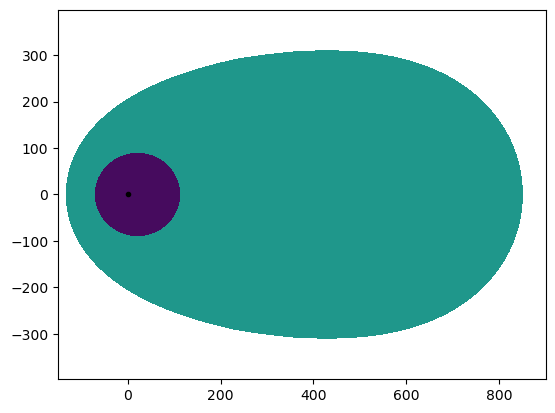

In [43]:
#решение
#координаты нейтральной линии тока
theta = np.linspace(1e-4, 3, 100) #нижняя половина линии тока
r = Q / ( 2 * np.pi) * theta / (-q * np.sin(theta))
xcap = r * np.cos(theta)
ycap = r * np.sin(theta)
#сетка внутри зоны захвата
xg = xcap * np.ones((100, len(xcap)))
yg = np.zeros_like(xg)
for i in range(len(xcap)):
    yg[:,i] = np.linspace(ycap[i] + 1e-3, - ycap[i] - 1e-3, 100)
#время добегания от точки координат до скважины
theta = np.arctan2(yg,xg)
tgrid = n * m * xg / q - Q * n * m / (2 * np.pi * q ** 2) * np.log(np.sin(theta + 2 * np.pi * q * yg / Q) / np.sin(theta))
plt.subplot(111, aspect=1)
plt.plot(0, 0, 'k.')
plt.contourf(xg, yg, tgrid, [0, 200, 10 * 365.25])
plt.xlim(-150, 900)

![результат](images_zso_1well_simple/zso_zones.png)